In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
from tensorflow.keras.datasets import mnist
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten,AveragePooling2D 

In [3]:
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 58s 5us/step
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


In [4]:
# Reshaping  and normilization of the data

X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_train = X_train.astype('float32') / 255

X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))
X_test = X_test.astype('float32') / 255

In [5]:
# One-hot encoding of the labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [6]:
# Building the CNN model
model = Sequential()
model.add(Conv2D(32, (5, 5), activation='relu',strides =(2,2),padding="Valid", input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (5, 5), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='SGD', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()
# Training the model
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=1)

c:\Users\silen\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 12, 12, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 2, 2, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,746 (206.04 KB)

 Trainable params: 52,746 (206.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8411 - loss: 0.6086 - val_accuracy: 0.9411 - val_loss: 0.2056
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9461 - loss: 0.1815 - val_accuracy: 0.9603 - val_loss: 0.1393
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9606 - loss: 0.1349 - val_accuracy: 0.9659 - val_loss: 0.1141
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9664 - loss: 0.1114 - val_accuracy: 0.9698 - val_loss: 0.0935
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9724 - loss: 0.0946 - val_accuracy: 0.9723 - val_loss: 0.0876
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9744 - loss: 0.0847 - val_accuracy: 0.9742 - val_loss: 0.0793
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9766 - loss: 0.0768 - val_accuracy: 0.9761 - val_loss: 0.0732
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9788 - loss: 0

In [7]:
print("Training Accuracy: ", history.history['accuracy'])
print("Validation Accuracy: ", history.history['val_accuracy'])

print("Training Loss: ", history.history['loss'])
print("Validation Loss: ", history.history['val_loss'])

Training Accuracy:  [0.8410666584968567, 0.9460833072662354, 0.9606333374977112, 0.9664166569709778, 0.97243332862854, 0.9744333624839783, 0.9766166806221008, 0.9787999987602234, 0.9804499745368958, 0.9817000031471252]
Validation Accuracy:  [0.941100001335144, 0.9603000283241272, 0.9659000039100647, 0.9697999954223633, 0.9722999930381775, 0.9742000102996826, 0.9761000275611877, 0.9785000085830688, 0.980400025844574, 0.9783999919891357]
Training Loss:  [0.6085535287857056, 0.18153642117977142, 0.13493309915065765, 0.11137982457876205, 0.09458685666322708, 0.0846739113330841, 0.07684560865163803, 0.06986140459775925, 0.06452994048595428, 0.060251880437135696]
Validation Loss:  [0.20560525357723236, 0.1393200308084488, 0.11410944908857346, 0.0935065820813179, 0.08759566396474838, 0.07926901429891586, 0.07315163314342499, 0.0696534812450409, 0.06274668872356415, 0.06304321438074112]


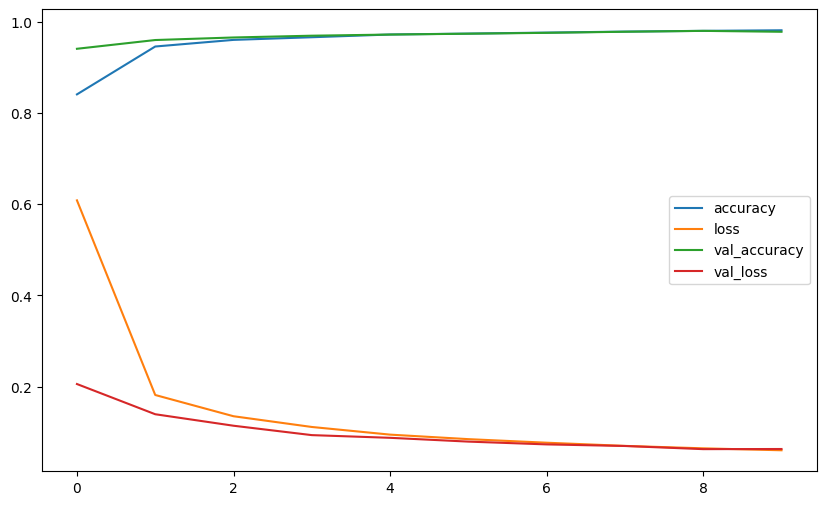

In [8]:
# Graphs for accuracy and loss
pd.DataFrame(history.history).plot(figsize=(10, 6))
plt.show()
